In [2]:
from skykatana import SkyMaskPipe   # the Skykatana code
import matplotlib.pyplot as plt
from pathlib import Path
import astropy.units as u
from astropy.coordinates import SkyCoord
import lsdb                         # if pixelating source catalogs in HATS format

# Quick intro or how to swing a Skykatana
-----------------
Starting from an input catalog of sources, a list of geometric shapes on the sky, or any healsparse map, ``Skykatana`` can create a pixelized mask in healsparse format, excluding areas due to various effects such as bright stars, patches with low depth, extended sources, etc. ``Skykatana`` is also designed to create star masks on-demand in the Rubin Science Plattaform over thousands of sq. degrees in just a few minutes with very limited memory resources and intersect masks from different surveys.

Basic usage: 
* **build_foot_mask(), build_patch_mask(), build_star_mask(), etc.** are used to produce individual masks
* **combine()** merge the maps create above to generate a final mask
* **plot()** can quickly visualize a mask by plotting randoms, make zooms and overplot stars
* **plot_moc()** can visualize a MOC version of a mask, with accurrate coordinate projections
* **makerans()** can generate randoms over any mask
* **apply()** can cut out sources outside of any given mask

When pixelating an input catalog of sources, ``Skykatana`` accepts a pandas daframe, an astropy table (or any format readable by astropy), or a HATS catalog. In the latter case, pixelization can be distributed across workers to deal with catalogs larger than available memory, such as LSST.

For creating bright star masks, ``Skykatana`` has special methods to query and pixelate large online catalogs in HATS format (such as Gaia), that work in systems with limited memory resources.

## Define inputs

In [3]:
BASEPATH = Path('../../skykatana_example_data/example_data/')

# Input HATS catalog (these are HSC galaxies)
HATSCAT = BASEPATH / 'hscx_minispring_gal/'

# Bright stars in HSC area
STARS_REGIONS     = BASEPATH / 'hsc_aux/stars_iband.parquet'
# Boxes around stars in HSC
BOX_STARS_REGIONS = BASEPATH / 'hsc_aux/starboxes_iband.parquet' 

# HSC patches and QA patch list ###################################### 
# See https://hsc-release.mtk.nao.ac.jp/schema/#pdr3.pdr3_wide.patch_qa
PATCH_FILE     = [BASEPATH / 'hsc_aux/tracts_patches_minispring.parquet']
QA_FILE        = BASEPATH / 'hsc_aux/patch_qa.csv'

# SFD dust extintion map (cut to the region covered by the example)
PROPMAP_FILE   = BASEPATH / 'hsc_aux/sfd_ebv_piece.fits'

# Some dummy geometrical regions
ELLIP_REGIONS = BASEPATH / 'hsc_aux/extended_sources.dat'
USER_CIRCLE_REGIONS = BASEPATH / 'hsc_aux/user_circs.dat' 
USER_POLY_REGIONS   = BASEPATH / 'hsc_aux/user_polys.dat'
USER_ZONE_REGIONS   = BASEPATH / 'hsc_aux/user_zones.dat'

## 1. Create the pipeline and run! 
-----------

After a SkyMaskPipe is instantiated, you can build masks (a.k.a. maps) due to various effects. These masks are independent boolean (or bit-packed boolean) **healsparse maps** we call `stages`. Stages are stored within the class along with some metadata. Some typical stages are:
* **`foot stage`** :: holds the footprint map created by pixelating discrete sources of a catalog **[SkyMaskPipe.footmask]**
* **`patch stage`** :: holds the map created from HSC patches matching some criteria **[SkyMaskPipe.patchmask]**
* **`property stage`** :: mask created from the combination of multiple healsparse propery maps matching some criteria **[SkyMaskPipe.propmask]**
* **`circ stage`** :: mask created from a list of circular sources, usually stars **[SkyMaskPipe.circmask]**
* **`box stage`** :: map created from a set of box regions **[SkyMaskPipe.boxmask]**
* **`ellip stage`** :: map created from a set of elliptical regions **[SkyMaskPipe.ellipmask]**

Once you have a few stages in the pipeline, their masks can be combined by `combine()` into:
* **`mask stage`** :: mask generated from the logical combination of the maps above **[SkyMaskPipe.mask]**   

In [4]:
mkp = SkyMaskPipe(order_out=15)
mkp.build_foot_mask(sources=lsdb.open_catalog(HATSCAT));
mkp.build_patch_mask(patchfile=PATCH_FILE, qafile=QA_FILE);
mkp.build_circ_mask(data=STARS_REGIONS, fmt='parquet');
mkp.build_box_mask(data=BOX_STARS_REGIONS, fmt='parquet');
mkp.build_ellip_mask(data=ELLIP_REGIONS, fmt='ascii');

BUILDING FOOT MASK >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
    Order :: 13
--- Pixelating HATS catalog
--- Foot mask area                         : 69.35790724770318
BUILDING PATCH MAP >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Processing ../../skykatana_example_data/example_data/hsc_aux/tracts_patches_minispring.parquet
    Order :: 13
    Patches with QA                       : 3708
    Patches with QA fulfilling conditions : 2003
    Surviving patch pixels                : 1062650
--- Patch mask area                           : 54.43575391135537
BUILDING CIRCLES MASK >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Pixelating circles from ../../skykatana_example_data/example_data/hsc_aux/stars_iband.parquet
    Order :: 15
    done
--- Circles mask area                        : 12.277230882152068
BUILDING BOXES MASK >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Pixelating boxes from ../../skykatana_example_data/example_data/hsc_aux/starboxes_iband.parquet
    Order :: 15
    don

<br>

**Just type the instance name to display useful information like orders, valid pixels, area, etc.**

In [21]:
mkp

footmask       : (ord/nside)cov=4/16   (ord/nside)sparse=13/8192  valid_pix=1353948  area= 69.36 deg² pix_size=  25.8"
patchmask      : (ord/nside)cov=4/16   (ord/nside)sparse=13/8192  valid_pix=1062650  area= 54.44 deg² pix_size=  25.8"
circmask       : (ord/nside)cov=4/16   (ord/nside)sparse=15/32768 valid_pix=3834656  area= 12.28 deg² pix_size=   6.4"
boxmask        : (ord/nside)cov=4/16   (ord/nside)sparse=15/32768 valid_pix=1737887  area=  5.56 deg² pix_size=   6.4"
ellipmask      : (ord/nside)cov=4/16   (ord/nside)sparse=15/32768 valid_pix=169105   area=  0.54 deg² pix_size=   6.4"

<br>

**Now combine into a "final" mask by intersecting footmask with patchmask and subtracting circles and boxes
(e.g. due to stars), and ellipses (e.g. due to large galaxies). If maps have different geometry such as
sparse order or coverage order, they will be reprojected on the fly to allow combination**

In [5]:
mkp.combine(positive=[('footmask','patchmask')], negative=['circmask','boxmask','ellipmask'], verbose=True);

[combine] aligning coverage for 'footmask' : c4 → c4
[combine] aligning coverage for 'patchmask' : c4 → c4
[combine] aligning coverage for 'circmask' : c4 → c4
[combine] aligning coverage for 'boxmask' : c4 → c4
[combine] aligning coverage for 'ellipmask' : c4 → c4
[combine] target=(o15, c4), work_order=13, r2=16
[combine:&] group of 2 stages: orders=[13, 13] -> work 13
[combine] done: order_out=15 (NSIDE=32768), order_cov=4 (NSIDE=16), valid_pix=14,312,202, area=45.823 deg², bit_packed=True


In [6]:
mkp  # now there is a new "mask" stage

footmask       : (ord/nside)cov=4/16   (ord/nside)sparse=13/8192  valid_pix=1353948  area= 69.36 deg² pix_size=  25.8"
patchmask      : (ord/nside)cov=4/16   (ord/nside)sparse=13/8192  valid_pix=1062650  area= 54.44 deg² pix_size=  25.8"
circmask       : (ord/nside)cov=4/16   (ord/nside)sparse=15/32768 valid_pix=3834656  area= 12.28 deg² pix_size=   6.4"
boxmask        : (ord/nside)cov=4/16   (ord/nside)sparse=15/32768 valid_pix=1737887  area=  5.56 deg² pix_size=   6.4"
ellipmask      : (ord/nside)cov=4/16   (ord/nside)sparse=15/32768 valid_pix=169105   area=  0.54 deg² pix_size=   6.4"
mask           : (ord/nside)cov=4/16   (ord/nside)sparse=15/32768 valid_pix=14312202  area= 45.82 deg² pix_size=   6.4"

<br>

**Combine performs the union ( specified between [] ) or intersection ( specified between() ) of any stage specified in the positive group. For example, the following would intersect footmask with patchmask, join the result with zonemask and subtract the three masks for circles, boxes and ellipses**

mkp.combine(positive=[('footmask','patchmask'),'zonemask'], negative=['circmask','boxmask','ellipmask']);

## 2. Generate randoms / Apply final mask to input catalog / Save pipeline to disk
---------

**Generate randoms over the mask stage**

In [10]:
rands = mkp.makerans(stage='mask', nr=500_000)
rands[:5]

ra,dec
float64,float64
217.0317095518112,0.7331634065253888
224.5373511314392,3.0642220551410375
217.44206607341766,1.7395248080214378
221.71443343162534,1.0998600539612031
216.9879573583603,-1.1881555807593203


<br>

**Generate randoms over any stage**

In [15]:
rands_in_holes = mkp.makerans(stage='ellipmask', nr=100_000)
rands_in_holes[:5]

ra,dec
float64,float64
223.81314396858212,2.687722491092348
223.7549990415573,2.795585374635337
223.75130295753476,2.6220092843271305
223.80658864974973,2.18948552704603
223.62743854522705,2.3103729155855297


<br>

**Use ``apply()`` to return a catalog filtered by any mask stage**

In [16]:
import lsdb
cat = lsdb.read_hats(HATSCAT, columns=['ra','dec']).compute()
srcs_masked = mkp.apply(stage='mask', cat=cat, columns=['ra','dec'])

6014995 sources within mask


<br>

**Save the SkyMaskPipe object to disk. This will create a directory where each stage is saved in FITS format using bit-encoding compression, plus a JSON file holding various metadata**

In [22]:
mkp.write('../../skykatana_example_data/mask/minispring', overwrite=True)

## 3. Explore some plots
-------------------

**The ``plot()`` method is suitable for very fast visualizations by plotting random (ra,dec) sources over the given stage**

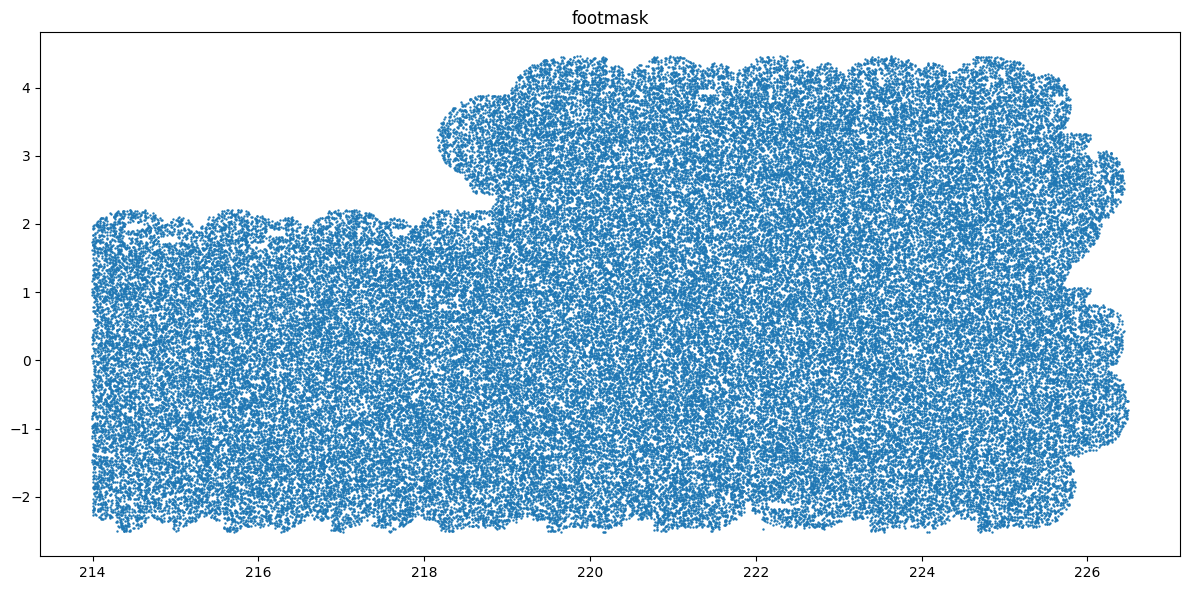

In [17]:
# Plot the footprint
mkp.plot(stage='footmask')

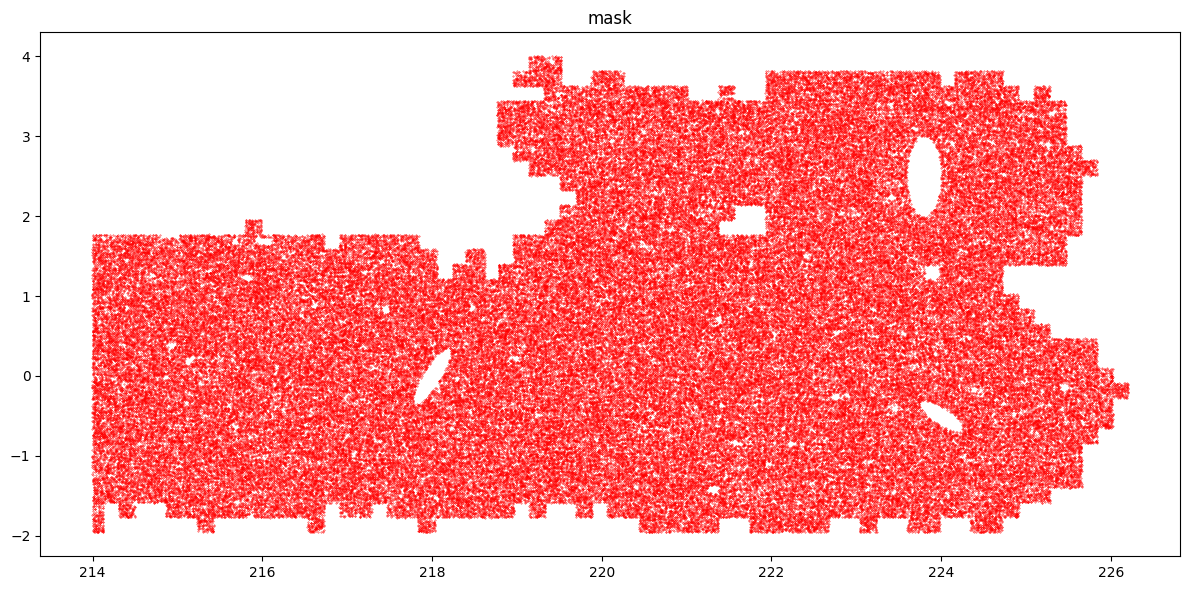

In [18]:
# Plot the final mask, 200k randoms
mkp.plot(stage='mask', nr=200_000, s=0.09, color='r')

<br>

**Plot a zoom of the final mask, include circles and boxes associated to stars masked out**

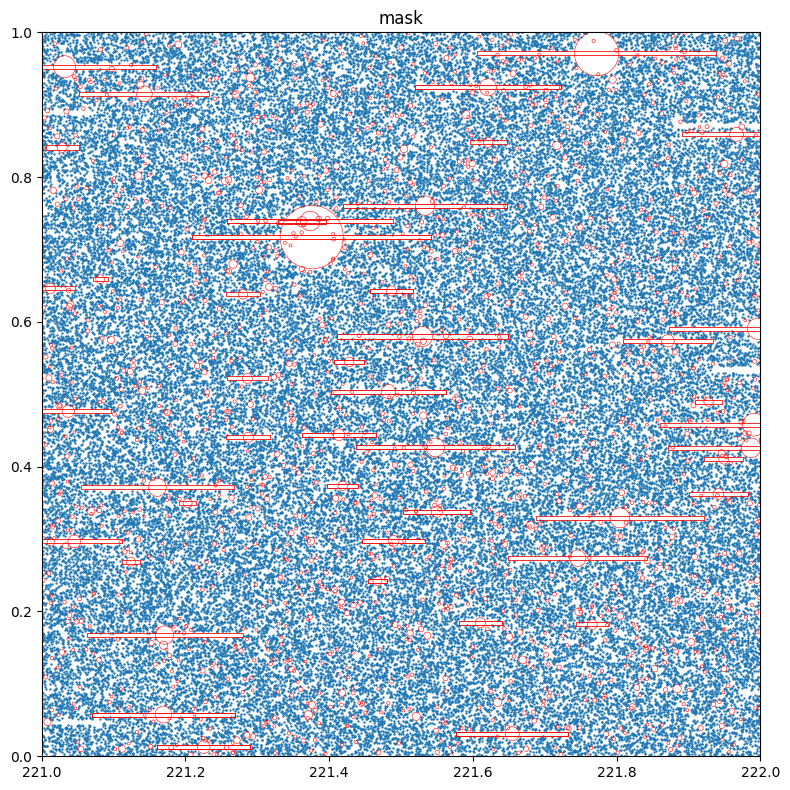

In [7]:
# Define two dictionaries with data files, format and column names
stars={'data':str(STARS_REGIONS), 'fmt':'parquet', 'columns':['ra','dec','radius']}
boxes={'data':str(BOX_STARS_REGIONS), 'fmt':'parquet', 'columns':['ra_c','dec_c','width','height']}
mkp.plot(stage='mask', nr=4_000_000, figsize=[8,8], clipra=[221,222], clipdec=[0,1], plot_circles=stars, plot_boxes=boxes)

<br>

**The ``plot_moc()`` method is adequate for accurrate visualizations in a WCS axes with suitable projections**

Looking pixels...
Found 1353948 pixels
Creating display moc from pixels...
MOC max_order is 13 --> degrading to 11...
Drawing plot...
Looking pixels...
Found 1062650 pixels
Creating display moc from pixels...
MOC max_order is 13 --> degrading to 11...
Drawing plot...


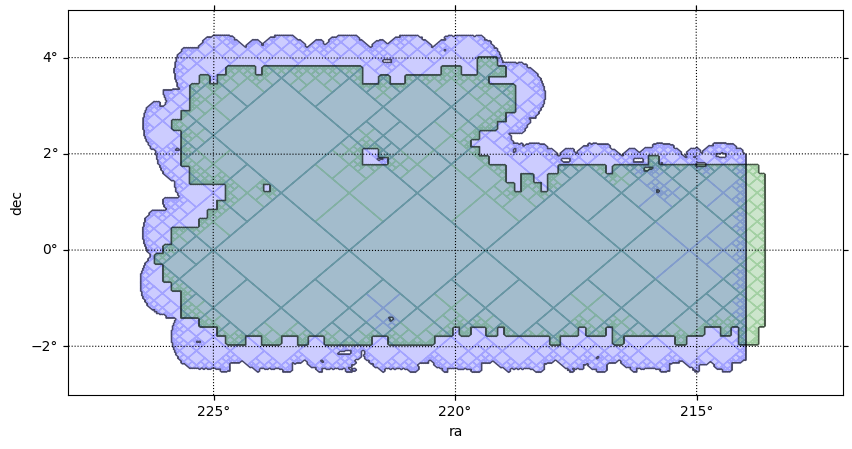

In [8]:
# Visualize stages by plotting their MOC in a WCS axes
center = SkyCoord(220*u.deg, 1*u.deg)   # specify the center of plot
fov    = 8 * u.deg                      # specify the field of view
fig, ax, wcs = mkp.plot_moc(stage='footmask', center=center, fov=fov, color='b') # MOC of the foot mask
fig, ax, wcs = mkp.plot_moc(stage='patchmask', ax=ax, wcs=wcs, color='g')        # MOC of the patch mask

<br>

**Now plot a zoom of a MOC. When zooming by choosing a smaller FOV, millions of high order pixels can show up and slow down plotting and/or consume lots of memory. Use clipra/clipdec to specify a region of interest and avoid processing pixels outside the chosen display window**

Looking pixels inside clip box...
Found 504524 pixels
Creating display moc from pixels...
MOC max_order is 15 --> no degrading...
Drawing plot...


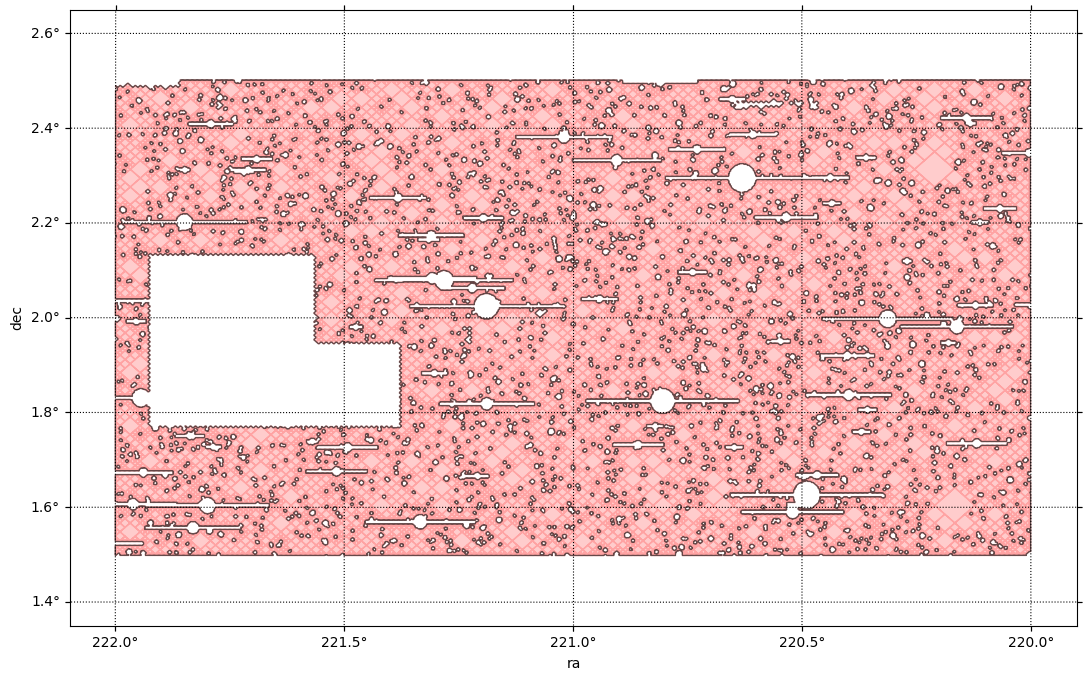

In [9]:
center = SkyCoord(221*u.deg, 2*u.deg)    # center of plot
fov    = [2.2*u.deg, 1.3*u.deg]          # field of view 
clipra = [220, 222]                      # ra limits for processing pixels
clipdec = [1.5, 2.5]                     # dec limits for processing pixels
fig, ax, wcs = mkp.plot_moc(stage='mask',  center=center, fov=fov,  color='r', clipra=clipra, clipdec=clipdec, figsize=[13,8])

<br>

**At some point it might be desirable to plot actual sources to check where they fall in a mask. Plot another zoom and overlay a catalog sources, in this case the sources we applied the mask before**

Looking pixels inside clip box...
Found 99104 pixels
Creating display moc from pixels...
MOC max_order is 15 --> no degrading...
Drawing plot...


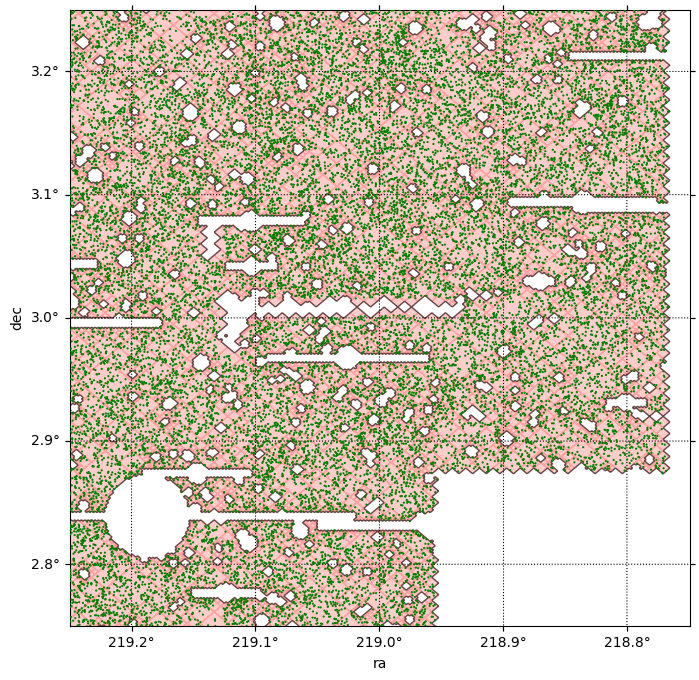

In [10]:
center = SkyCoord(219*u.deg, 3*u.deg)    # center of plot
fov    = [0.5*u.deg, 0.5*u.deg]          # field of view 
clipra = [218.5, 219.3]                  # ra limits for processing pixels
clipdec = [2.7, 3.5]                     # dec limits for processing pixels
fig, ax, wcs = mkp.plot_moc(stage='mask',  center=center, fov=fov,  color='r', alpha=0.2, clipra=clipra, clipdec=clipdec, figsize=[8,8])
fig, ax, wcs = mkp.plot_srcs(srcs_masked['ra'], srcs_masked['dec'], ax=ax, wcs=wcs, s=10, alpha=1, color='g', zorder=10)

## 4. Build methods: from geometry to masks

**``Skykatana`` has methods to pixelate and generate masks from a variety of geometric shapes**

In [ ]:
mkp = SkyMaskPipe(order_out=15)
mkp.build_foot_mask(sources=lsdb.open_catalog(HATSCAT), mapping=False);       # from individual point sources
mkp.build_prop_mask(prop_maps=PROPMAP_FILE,thresholds=1.3,comparisons='lt');  # from healsparse property maps
mkp.build_circ_mask(data=STARS_REGIONS, fmt='parquet');                       # from circular regions
mkp.build_box_mask(data=BOX_STARS_REGIONS, fmt='parquet');                    # from box regions
mkp.build_ellip_mask(data=ELLIP_REGIONS, fmt='ascii');                        # from elliptical regions
mkp.build_poly_mask(data=USER_POLY_REGIONS, fmt='ascii');                     # from quadrangular sky polygons
mkp.build_zone_mask(data=USER_ZONE_REGIONS, fmt='ascii');                     # from zones delimited by ra-dec boundaries
mkp.build_patch_mask(patchfile=PATCH_FILE, qafile=QA_FILE);                   # from a sets of patches with custom filtering

**Each the these **build** methods store its calling arguments in dictionaries under `_params`. In this way, all the metadata used to create masks is saved in the pipeline and kept for record**

In [9]:
mkp._params['footmask']

{'sources': '../../skykatana_example_data/example_data/hscx_minispring_gal',
 'order_foot': 13,
 'order_cov': 4,
 'columns': ('ra', 'dec'),
 'remove_isopixels': False,
 'erode_borders': False,
 'bit_packing': True,
 'pixels': np.int64(1353948),
 'area_deg2': np.float64(69.35790724770318)}

**All ``build_`` methods create a stage of a given name, e.g. "footmask", "propmask", "circmask", etc. But you can add your own stages with any name or origin as long as they are healsparse boolean masks**

In [ ]:
# Create a bogus cirrus mask and add it to the pipeline
import healsparse as hsp, numpy as np
from mocpy import MOC
from astropy.coordinates import SkyCoord
moc = MOC.from_zone(SkyCoord([[220, -5], [222, 0.3]], unit="deg"), max_depth=15)
cirrus = hsp.HealSparseMap.make_empty(2**4, 2**15, dtype=np.bool_)
pixels = moc.flatten().astype(np.int64)
cirrus.update_values_pix(pixels, True)
cirrusmask = cirrus.as_bit_packed_map()

mkp.cirrusmask = cirrusmask

In [ ]:
# Then you can work, combine and plot as with any other stage
mkp.combine(positive=['footmask','patchmask','cirrusmask'], negative=['circmask','boxmask','ellipmask']);

## 5. Creating star masks on demand in RSP

**Skykatana has methods to create custom bright star masks over any stage or healsparse map. The code can query large HATS catalog on-demand such as GAIA, add star radii with user-defined functions, pixelize the corresponding circles, and return a healsparse mask. It is also highly adapted to run in the Rubin Science Plataform (RSP) and low memory environments**

-------------------
**STEP 1 : define star radius function and query dictionary**

In [ ]:
from functools import partial

# This function determines the radius of stars that will be masked. It can be completely customized according to band, 
# completeness level, or any other parameter. The only requirement is that it must take an input df (e.g. with 
# star magnitudes) and add a "radius" column (in deg)

def radfunction(df: pd.DataFrame, **kwargs):
    mag = 'phot_g_mean_mag'                          # define magnitude to use
    band = kwargs.get('band', 'r')                   # extract band
    completeness = kwargs.get('completeness', 0.85)  # extract completeness level
    if band == 'r':
        if completeness==0.85:
            nconst, alpha = (7538.,-0.38)  # normalization constant and exponential slope alpha
            magcut        =  17.           # magnitude cutoff above which stars get a fixed faint_radius
            faintrad      =  11.8          # faint radius [arcsec]
        elif completeness==0.80:
            pass
    # Set radius
    df['radius'] = np.where(df[mag] <= magcut, nconst*np.exp(alpha*df[mag])/3600., faintrad/3600.)

# Star query dictionary. This controls where and which stars will be queried, as well as some performance
# parameters to keep memory usage under control. If the area searched is very large, Skykatana can break
# it into chunks that are queried, processed and coadded at the end, enabling procesing of thousands of sq degrees

starq = {'search_stage': mkp.mask,                       # The stage where we want to retrieve stars
         'cat':"https://data.lsdb.io/hats/gaia_dr3",     # URL of HATS catalog, e.g. for Gaia
         'columns':['ra','dec','phot_g_mean_mag','b'],   # Columns to retrieve from it
         'gaia_gmag_lims':[7,19],                        # G_band magnitude limits
         'gaia_b_lims':[-20,20],                         # Galactic latitude range to exclude the MW disk
         'radfunction': partial(radfunction, completeness=0.85, band='r'),  # Star radius function. Must be wrapped with partial()
         'max_area_single': 1000.,                       # Optional - max area to make in a single query
         'target_chunk_area': 1000.,                     # Optional - target area of chuncks that the search_stage is splitted
         'coarse_order_bfs': 5                           # Optional - coarse order to perform chunking
         }

-------------------
**STEP 2 : set up a dask client**

In [ ]:
from dask.distributed import Client
client = Client(n_workers=2, threads_per_worker=1, memory_limit="8GiB")

-------------------
**STEP 3 : get stars and build the mask**

In [ ]:
mkp.build_star_mask_online(starq=starq)

<br>

**Now we have a new starmask stage !**

In [27]:
mkp

footmask       : (ord/nside)cov=4/16   (ord/nside)sparse=13/8192  valid_pix=1353948  area= 69.36 deg² pix_size=  25.8"
patchmask      : (ord/nside)cov=4/16   (ord/nside)sparse=13/8192  valid_pix=1062650  area= 54.44 deg² pix_size=  25.8"
circmask       : (ord/nside)cov=4/16   (ord/nside)sparse=15/32768 valid_pix=3834656  area= 12.28 deg² pix_size=   6.4"
boxmask        : (ord/nside)cov=4/16   (ord/nside)sparse=15/32768 valid_pix=1737887  area=  5.56 deg² pix_size=   6.4"
ellipmask      : (ord/nside)cov=4/16   (ord/nside)sparse=15/32768 valid_pix=169105   area=  0.54 deg² pix_size=   6.4"

## 6. Creating masks from property maps
----------

**While patches are geometric constructions specific to HSC, in general you can also restrict to areas of the sky meeting certain conditions if you have healsparse propery maps available**

In [22]:
# The map file here contains a small region of the dust extinction map of Schlegel, Finkbeiner & Davies in healsparse format. 
# This (arbitrary) cut will discard areas with very high extinction
mkp.build_prop_mask(prop_maps=PROPMAP_FILE,thresholds=1.3,comparisons='lt')
mkp.combine(positive=[('footmask','patchmask','propmask')]);

BUILDING PROPERTY MAP >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Processing ../../skykatana_example_data/example_data/hsc_aux/sfd_ebv_piece.fits
--- Propertymap coverage order changed to 4
--- Propertymap sparse order changed to 15
--- Propertymap mask area                       : 113.86116591708016
[combine] aligning coverage for 'footmask' : c4 → c4
[combine] aligning coverage for 'patchmask' : c4 → c4
[combine] aligning coverage for 'propmask' : c4 → c4
[combine] target=(o15, c4), work_order=13, r2=16
[combine:&] group of 3 stages: orders=[13, 13, 15] -> work 13
[combine] done: order_out=15 (NSIDE=32768), order_cov=4 (NSIDE=16), valid_pix=14,497,392, area=46.416 deg², bit_packed=True


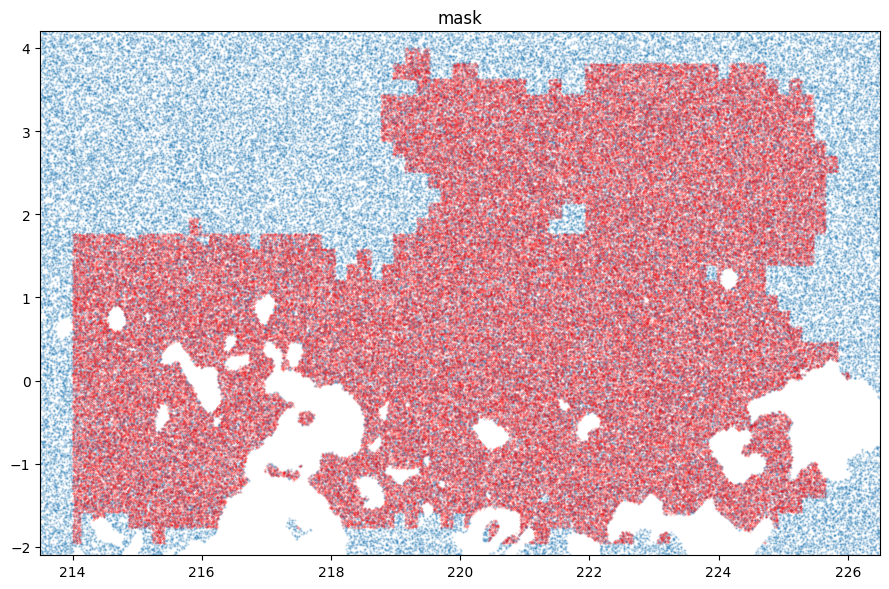

In [23]:
# Overlay the SFD extincion mask and the new combined final mask
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=[9,6])
mkp.plot(stage='propmask', nr=200_000, alpha=0.2, clipra=[213.5, 226.5], clipdec=[-2.1,4.2], ax=ax)
mkp.plot(stage='mask', nr=200_000, s=0.09, color='r', alpha=0.3 , ax=ax)

## 7. Creating masks from filtered patches
----------

**In the HSC-SSP survey, patches are characterized by properties like seeing or depth. Lets create a mask for the patches above a given minimum i-band depth**

In [12]:
mkp_custom = SkyMaskPipe()
mkp_custom.build_foot_mask(sources=lsdb.open_catalog(HATSCAT))
mkp_custom.build_patch_mask(patchfile=PATCH_FILE, qafile=QA_FILE, filt='(imag_psf_depth>26.3)')
mkp_custom.combine(positive=[('footmask','patchmask')]);

BUILDING FOOT MASK >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
    Order :: 13
--- Pixelating HATS catalog
--- Foot mask area                         : 69.35790724770318
BUILDING PATCH MAP >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Processing ../../skykatana_example_data/example_data/hsc_aux/tracts_patches_minispring.parquet
    Order :: 13
    Patches with QA                       : 3708
    Patches with QA fulfilling conditions : 1167
    Surviving patch pixels                : 633006
--- Patch mask area                           : 32.426630443148184
[combine] aligning coverage for 'footmask' : c4 → c4
[combine] aligning coverage for 'patchmask' : c4 → c4
[combine] target=(o15, c4), work_order=13, r2=16
[combine:&] group of 2 stages: orders=[13, 13] -> work 13
[combine] done: order_out=15 (NSIDE=32768), order_cov=4 (NSIDE=16), valid_pix=9,693,840, area=31.036 deg², bit_packed=True


Looking pixels...
Found 14312202 pixels
Creating display moc from pixels...
MOC max_order is 15 --> degrading to 12...
Drawing plot...
Looking pixels...
Found 9693840 pixels
Creating display moc from pixels...
MOC max_order is 15 --> degrading to 12...
Drawing plot...


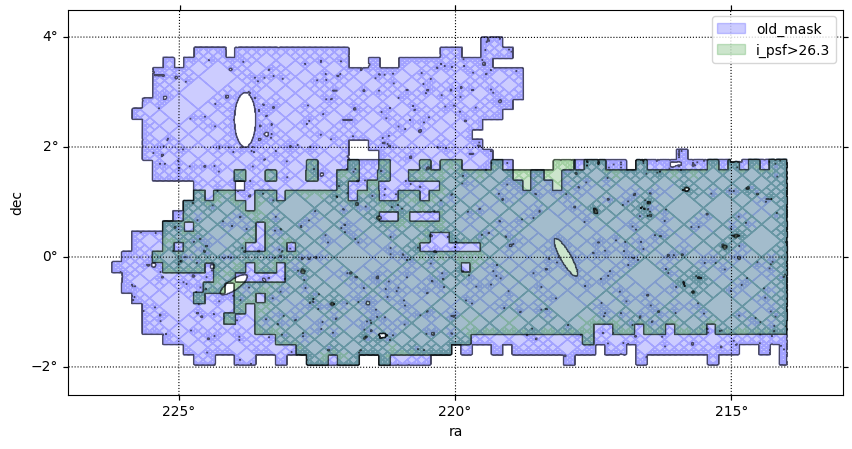

In [13]:
center = SkyCoord(220*u.deg, 1*u.deg)   # center of plot
fov    = 7 * u.deg                      # field of view
fig, ax, wcs = mkp.plot_moc(stage='mask', center=center, fov=fov, color='b', label='old_mask')
fig, ax, wcs = mkp_custom.plot_moc(stage='mask', ax=ax, wcs=wcs, color='g', label='i_psf>26.3')
plt.legend();

* Note setting `filt=None` applies no filtering and therefore all patches will be pixelized into the patchmask.
* Note leaving `filt` unspecified will use the default filtering recipe, which impose minimum values on gri depths in order to select a more uniform coverage :: (gmag_psf_depth>26.2) and (rmag_psf_depth>25.9) and (imag_psf_depth>25.7)